In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
from utils import load_data
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
load_dotenv()
fred_api = os.getenv("FRED_API_KEY")
df = load_data(fred_api)
df

,DATE,DXY,VIX,FEDFUNDS,ECB_RATE,TRADE_BAL,INT_DIFF,DXY_next,YEAR,MONTH,QUARTER
0,2006-01-31,99.4311,12.036000,4.29,1.25,-66967.0,3.04,99.7695,2006,1,1
1,2006-02-28,99.7695,12.471053,4.49,1.25,-62308.0,3.24,100.5600,2006,2,1
2,2006-03-31,100.5600,11.693913,4.59,1.50,-62397.0,3.09,98.1412,2006,3,1
3,2006-04-30,98.1412,11.847368,4.79,1.50,-62603.0,3.29,97.7705,2006,4,2
4,2006-05-31,97.7705,14.454545,4.94,1.50,-64818.0,3.44,98.2483,2006,5,2
...,...,...,...,...,...,...,...,...,...,...,...
236,2025-09-30,120.1368,15.789091,4.22,2.00,-49168.0,2.22,121.3859,2025,9,3
237,2025-10-31,121.3859,18.086522,4.09,2.00,-31102.0,2.09,121.0527,2025,10,4
238,2025-11-30,121.0527,19.769500,3.88,2.00,-56026.0,1.88,119.7456,2025,11,4
239,2025-12-31,119.7456,15.548182,3.72,2.00,-72900.0,1.72,117.8996,2025,12,4


In [3]:
split_idx = int(len(df) * 0.75)

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

X_train = train.drop(["DXY_next", "DATE"], axis=1)
y_train = train["DXY_next"]

X_test = test.drop(["DXY_next", "DATE"], axis=1)
y_test = test["DXY_next"]

In [4]:
test

,DATE,DXY,VIX,FEDFUNDS,ECB_RATE,TRADE_BAL,INT_DIFF,DXY_next,YEAR,MONTH,QUARTER
180,2021-01-31,111.9511,24.910000,0.09,-0.5,-62826.0,0.59,112.8306,2021,1,1
181,2021-02-28,112.8306,23.140526,0.08,-0.5,-65630.0,0.58,113.8234,2021,2,1
182,2021-03-31,113.8234,21.843043,0.07,-0.5,-65658.0,0.57,112.0839,2021,3,1
183,2021-04-30,112.0839,17.416190,0.07,-0.5,-65115.0,0.57,110.7576,2021,4,2
184,2021-05-31,110.7576,19.760500,0.06,-0.5,-65779.0,0.56,112.5533,2021,5,2
...,...,...,...,...,...,...,...,...,...,...,...
236,2025-09-30,120.1368,15.789091,4.22,2.0,-49168.0,2.22,121.3859,2025,9,3
237,2025-10-31,121.3859,18.086522,4.09,2.0,-31102.0,2.09,121.0527,2025,10,4
238,2025-11-30,121.0527,19.769500,3.88,2.0,-56026.0,1.88,119.7456,2025,11,4
239,2025-12-31,119.7456,15.548182,3.72,2.0,-72900.0,1.72,117.8996,2025,12,4


In [5]:
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (180, 9)
Test set shape: (61, 9)


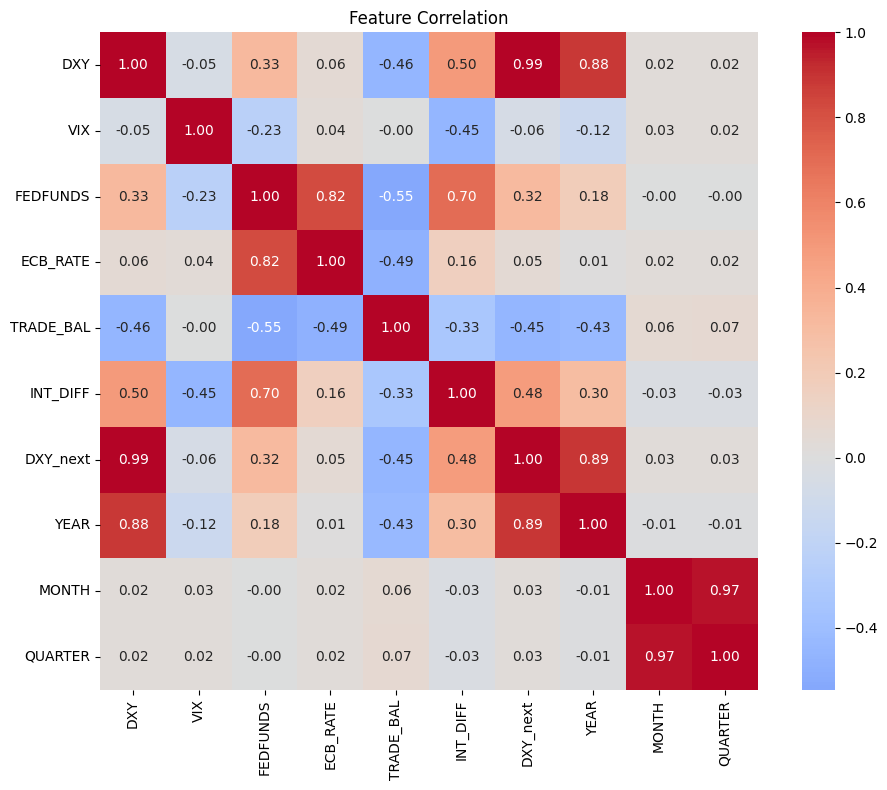

In [6]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation")
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    HuberRegressor,
    SGDRegressor,
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
import pandas as pd

cv = TimeSeriesSplit(n_splits=5)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae":  "neg_mean_absolute_error",
    "mape": "neg_mean_absolute_percentage_error",
    "r2":   "r2",
}
refit_metric = "rmse"

models = {
    "LinearRegression": (
        Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
        {
            "model__fit_intercept": [True, False],
        },
    ),
    "Ridge": (
        Pipeline([("scaler", StandardScaler()), ("model", Ridge(random_state=42))]),
        {
            "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
            "model__solver": ["auto", "svd", "cholesky", "lsqr", "saga"],
        },
    ),
    "Lasso": (
        Pipeline([("scaler", StandardScaler()), ("model", Lasso(random_state=42, max_iter=10000))]),
        {
            "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
            "model__selection": ["cyclic", "random"],
        },
    ),
    "ElasticNet": (
        Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(random_state=42, max_iter=10000))]),
        {
            "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
            "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        },
    ),
    "BayesianRidge": (
        Pipeline([("scaler", StandardScaler()), ("model", BayesianRidge())]),
        {
            "model__alpha_1": [1e-7, 1e-6, 1e-5],
            "model__alpha_2": [1e-7, 1e-6, 1e-5],
            "model__lambda_1": [1e-7, 1e-6, 1e-5],
            "model__lambda_2": [1e-7, 1e-6, 1e-5],
        },
    ),
    "HuberRegressor": (
        Pipeline([("scaler", StandardScaler()), ("model", HuberRegressor(max_iter=500))]),
        {
            "model__epsilon": [1.1, 1.35, 1.5, 2.0],
            "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
        },
    ),
    "SGDRegressor": (
        Pipeline([("scaler", StandardScaler()), ("model", SGDRegressor(random_state=42, max_iter=5000))]),
        {
            "model__loss": ["squared_error", "huber", "epsilon_insensitive"],
            "model__penalty": ["l2", "l1", "elasticnet"],
            "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
            "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
            "model__eta0": [0.001, 0.01, 0.1],
        },
    ),
}

results = []
best_estimators = {}

for name, (pipe, grid) in models.items():
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=scoring,
        refit=refit_metric,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    gs.fit(X_train, y_train)

    best_estimators[name] = gs.best_estimator_

    idx = gs.best_index_
    row = {"model": name, "best_params": gs.best_params_}
    for metric in scoring:
        mean = gs.cv_results_[f"mean_test_{metric}"][idx]
        std  = gs.cv_results_[f"std_test_{metric}"][idx]

        if metric != "r2":
            mean, std = -mean, std
        row[f"{metric}_mean"] = mean
        row[f"{metric}_std"]  = std
    results.append(row)

results_df = pd.DataFrame(results).sort_values("rmse_mean")

best_name = results_df.iloc[0]["model"]
best_model = best_estimators[best_name]
y_pred = best_model.predict(X_test)

print(f"\n=== Holdout test performance: {best_name} ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

=== Holdout test performance: Lasso ===
RMSE: 1.8705
MAE:  1.5431
MAPE: 0.0128
R²:   0.8157


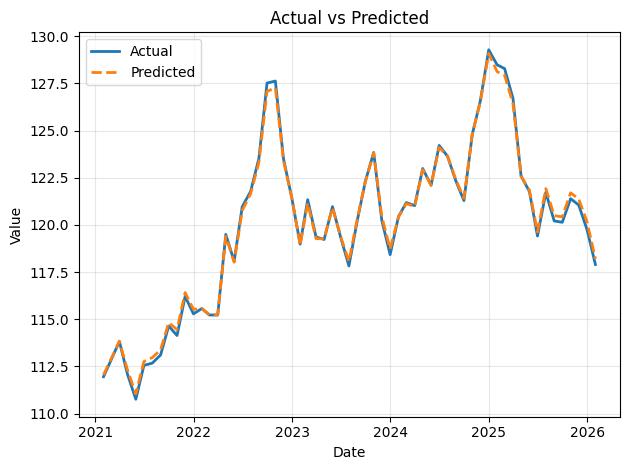

In [8]:
plt.plot(test["DATE"], test["DXY"], label="Actual", color="#1f77b4", linewidth=2)
plt.plot(test["DATE"], y_pred, label="Predicted", color="#ff7f0e", linewidth=2, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

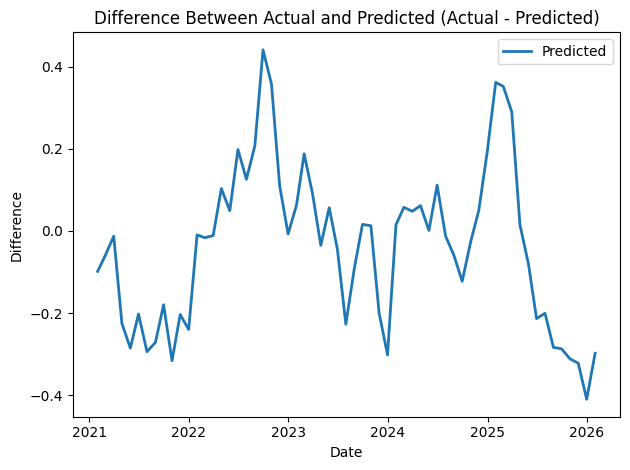

In [9]:
plt.plot(test["DATE"], test["DXY"] - y_pred, label="Predicted", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Difference")
plt.title("Difference Between Actual and Predicted (Actual - Predicted)")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:

from sklearn.metrics import mean_squared_error

y_naive = X_test["DXY"].values
rmse_naive = np.sqrt(mean_squared_error(y_test, y_naive))

rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Naive (DXY_next = DXY) RMSE: {rmse_naive:.4f}")
print(f"Your model RMSE:            {rmse_model:.4f}")
print(f"Skill vs naive: {1 - rmse_model/rmse_naive:.3%}")

Naive (DXY_next = DXY) RMSE: 1.8987
Your model RMSE:            1.8705
Skill vs naive: 1.489%


# Status Report - April 14

## Noticable Error Found From Exploratory Analysis

While attempting to predict one-month-ahead values of the U.S. Dollar Index (DXY) using linear regression models with macroeconomic features (VIX, Fed Funds Rate, ECB Rate, Trade Balance, Interest Rate Differential) over the period January 2006 through January 2026. A suite of seven linear models was tuned via grid search with time-series cross-validation, and the best model was evaluated on a held-out test set covering the final 25% of the sample.

At first glance, the results appear excellent: predicted and actual DXY levels track each other almost perfectly on the test set, producing a visually compelling forecast. This apparent success is illusory. A formal comparison against a trivial persistence baseline — simply using the current month's DXY as the prediction for next month — reveals that the tuned model achieves only a 1.5% improvement in RMSE (1.8705 vs. 1.8987). This improvement is negligible and almost certainly within the noise of the split.

The underlying issue is a combination of target formulation and feature construction: the target variable DXY_next is highly autocorrelated with the feature DXY, and the best linear model has effectively learned the identity function DXY_next ≈ DXY, with macro features contributing only cosmetic adjustments. The visually impressive fit is, in substance, a persistence forecast.

The single most important diagnostic for any time-series forecasting model is comparison against a naive persistence baseline: the prediction that next period's value equals this period's value. For a highly autocorrelated series like a currency index, this baseline is notoriously hard to beat and is the standard benchmark in the forecasting literature. From our model, we see a 1.5% improvement in RMSE; however, is not meaningful. Small perturbations to the train/test split, the CV fold structure, or the random seed could easily flip this number negative. There is no evidence that the macro features provide predictive value beyond what is already contained in the current DXY level. Since DXY is a slow varying series, whose month-to-month changes are typically on the order of 1–2%, against a base value near 100. Therefore, from the heatmap, the correlation between DXY and DXY_next is approximately 0.99. When DXY is included as a feature and DXY_next is used as the target, a linear model will — correctly, from an optimization standpoint — place nearly all of its weight on DXY with a coefficient close to 1.0. The resulting prediction is indistinguishable from the input, which is indistinguishable from the target, which produces a near-perfect overlay plot.

The visual impression of accuracy is therefore a direct artifact of plotting a nearly-identity mapping against its own input, shifted by one period. It is not evidence that the model has learned anything about the economic drivers of the dollar. 

** **

## Looking Forward

> Reformulate the target
>> Replace DXY_next with the next-period log return: `np.log(DXY).diff().shift(-1)`. Returns are near-stationary and not dominated by their own lag, so any predictive signal you find will be real rather than an artifact of autocorrelation.

> Feature Rebuild
>> Drop DXY from the feature set entirely. Replace macro features with their first differences: change in VIX, change in Fed Funds, change in ECB rate, change in interest rate differential, change in trade balance. Keep VIX level as well since it is roughly stationary on its own. Add two or three lags of DXY returns as autoregressive features.

> Re-Examine Models
>> Rerun GridSearchCV on the new formulation. In the meantime, add in more complex model features like LSTM.

** **

## Data

Our data are primarily from Federal Reserve St. Louis, accessed via FRED API. The dataset consists of 241 monthly observations from January 2006 to January 2026. 